

### Part A - Theoretical Questions (Machine Learning & Linear Regression)

Q1. What is Machine Learning? Explain the main types of Machine Learning with examples.
Machine Learning (ML) is a subset of artificial intelligence (AI) that focuses on building systems capable of learning from data, identifying patterns, and making decisions with minimal human intervention. Instead of being explicitly programmed to perform a task, these systems learn and improve from experience.

The main types of Machine Learning are:

* **Supervised Learning:** The model is trained on labeled data, meaning the input data is paired with the correct output.
* *Example:* Predicting house prices based on features like square footage and location (the model learns from past sales data where the price is known).


* **Unsupervised Learning:** The model is given data without explicit instructions on what to do with it. The system tries to learn the underlying structure or distribution in the data to discover hidden patterns.
* *Example:* Customer segmentation in marketing, where an algorithm groups customers into distinct clusters based on purchasing behavior without prior labels.


* **Reinforcement Learning:** An agent learns to make decisions by performing actions in an environment and receiving rewards or penalties. The goal is to maximize the cumulative reward.
* *Example:* Training an AI to play chess or navigate a robot through a maze.



---

Q2. What is Supervised Learning? Explain the difference between Regression and Classification.
Supervised learning is an ML approach defined by its use of labeled datasets to train algorithms that classify data or predict outcomes accurately.

The primary difference between Regression and Classification lies in the type of output variable they predict:

* **Regression:** Used when the target variable (output) is continuous or numerical. It predicts a quantity.
* *Example:* Predicting the exact price of a house ($350,000) or a person's weight.


* **Classification:** Used when the target variable is categorical or discrete. It classifies data into specific classes or categories.
* *Example:* Predicting whether an email is "Spam" or "Not Spam", or whether a tumor is "Malignant" or "Benign".



---

Q3. What is Linear Regression? Write the Linear Regression equation and explain intercept and coefficient.
Linear Regression is a supervised learning algorithm used for predicting a continuous dependent variable based on one or more independent variables. It assumes a linear relationship between the input variables ($X$) and the single output variable ($Y$).

The Multiple Linear Regression equation is written as:


$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n$$

* **Intercept ($\beta_0$):** This represents the expected mean value of $y$ when all independent variables ($x_1, x_2, \dots, x_n$) are equal to zero. Geometrically, it is where the regression line crosses the y-axis.
* **Coefficient ($\beta_1, \beta_2, \dots, \beta_n$):** These are the weights assigned to the features. A coefficient represents the expected change in the dependent variable ($y$) for a one-unit change in the respective independent variable ($x$), holding all other variables constant.

---

Q4. Explain the following evaluation metrics used in Linear Regression:

*
SSE (Sum of Squared Errors): The sum of the squared differences between the actual values ($y_i$) and the predicted values ($\hat{y}_i$). It measures the total error of the model.



$$SSE = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$


*
MSE (Mean Squared Error): The average of the squared errors. It penalizes larger errors more than smaller ones, making it useful for optimizing models.



$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$


*
RMSE (Root Mean Squared Error): The square root of the MSE. It brings the unit of the error back to the original unit of the target variable, making it easier to interpret.



$$RMSE = \sqrt{MSE}$$


*
R² Score (Coefficient of Determination): A statistical measure that represents the proportion of the variance for a dependent variable that's explained by an independent variable(s). It ranges from 0 to 1, where 1 indicates perfect prediction.


*
Adjusted R²: A modified version of R² that adjusts for the number of predictors in the model. Unlike R², which always increases when you add a new feature, Adjusted R² only increases if the new term improves the model more than would be expected by chance.



$$Adjusted R^2 = 1 - \left[ \frac{(1 - R^2)(n - 1)}{n - k - 1} \right]$$



*(where $n$ is the number of observations and $k$ is the number of independent variables).*

---

Q5. Explain the Machine Learning workflow steps from data collection to model evaluation.

1. **Data Collection:** Gathering raw data from databases, APIs, files, or sensors. The quality of this data dictates the success of the model.
2. **Data Preprocessing & Cleaning:** Handling missing values, removing duplicates, dealing with outliers, and formatting data.
3. **Exploratory Data Analysis (EDA):** Visualizing and analyzing the data to understand distributions, relationships, and correlations between variables.
4. **Feature Engineering & Selection:** Creating new meaningful features from existing ones, encoding categorical variables, scaling numerical data, and selecting the most relevant features for the model.
5. **Data Splitting:** Dividing the dataset into a training set (to train the model) and a testing set (to evaluate its performance on unseen data).
6. **Model Selection & Training:** Choosing the appropriate algorithm (e.g., Linear Regression) and feeding the training data into the algorithm so it can learn the underlying patterns.
7. **Model Evaluation:** Testing the trained model on the testing set and calculating metrics (like RMSE and R²) to assess how well it generalizes to unseen data.

---

### Part B - Practical Questions (Google Colab Notebook)

You can copy and paste the following Python code directly into your Google Colab notebook to fulfill the submission requirements.

*(Note: The Boston Housing dataset was removed from Scikit-Learn due to ethical concerns, so this code fetches it directly from a trusted public data repository.)*

#### Q6.

Load the Dataset and Basic Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# Load the Boston Housing dataset
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df = pd.read_csv(url)

# Q6: Basic Data Exploration
print("--- HEAD ---")
display(df.head())

print("\n--- INFO ---")
df.info()

print("\n--- DESCRIBE ---")
display(df.describe())

--- HEAD ---


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2



--- INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB

--- DESCRIBE ---


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


#### Q7.

Exploratory Data Analysis

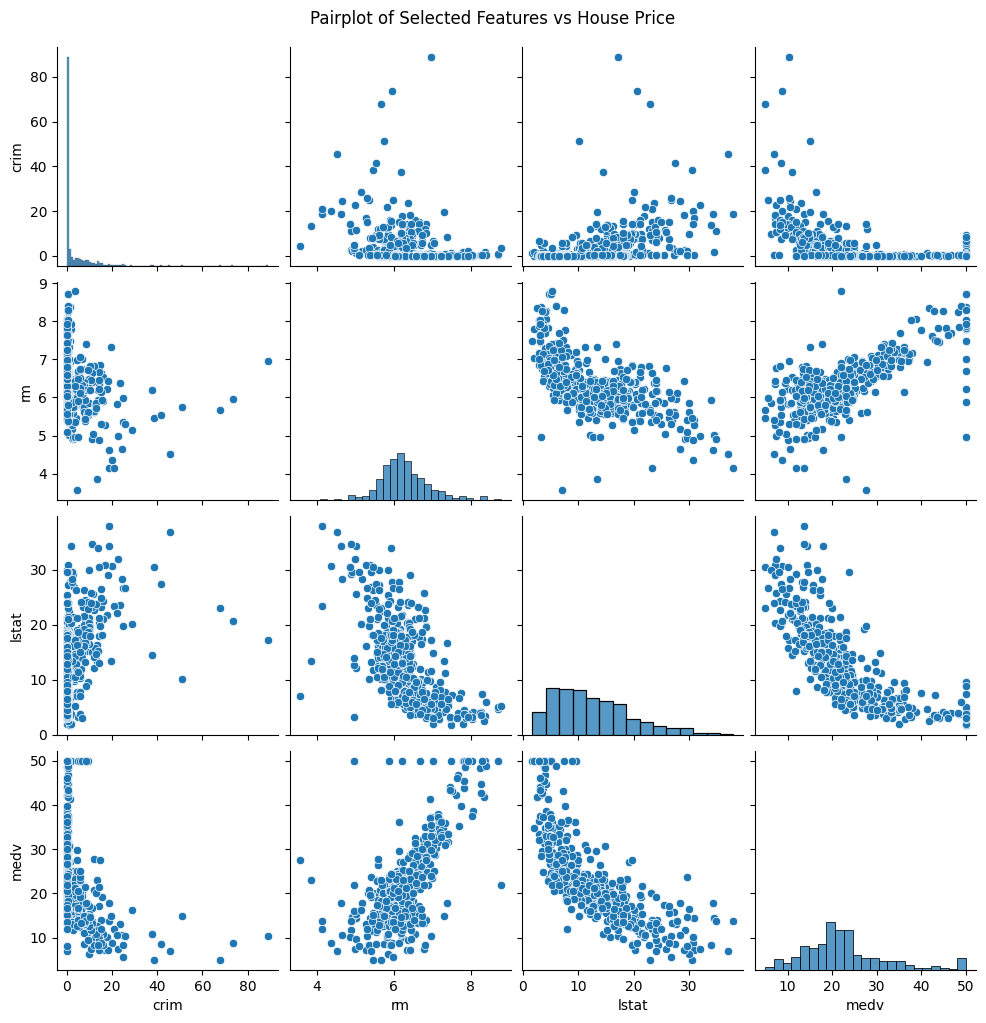

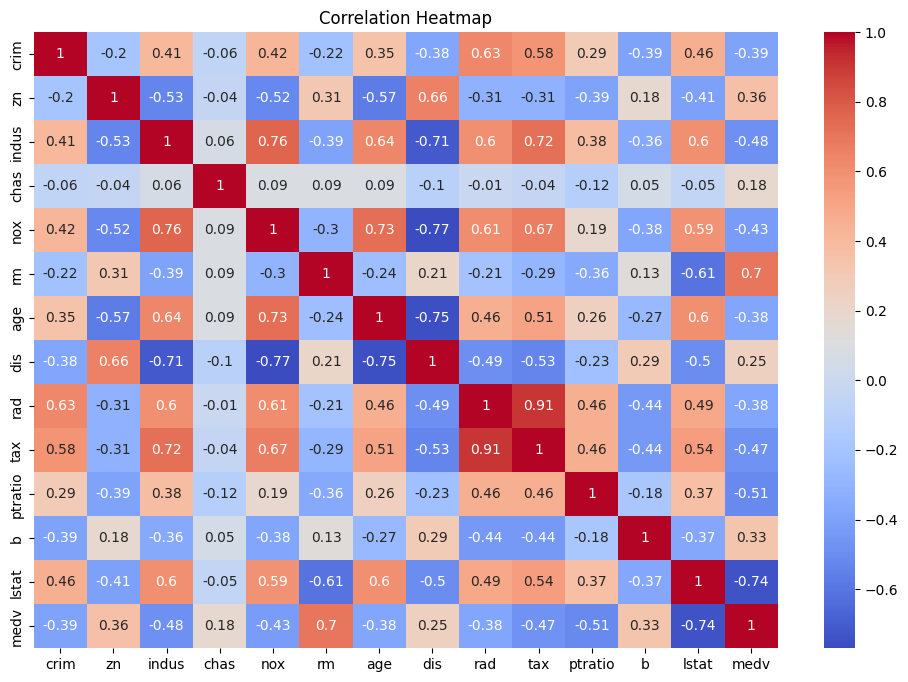

Features most positively correlated with medv: rm (0.70)
Features most negatively correlated with medv: lstat (-0.74)


In [2]:
# Create Pairplot (Selecting a subset for readability, or use df for all)
sns.pairplot(df[['crim', 'rm', 'lstat', 'medv']])
plt.suptitle("Pairplot of Selected Features vs House Price", y=1.02)
plt.show()

# Create Correlation Heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr().round(2)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Identify Highly Correlated Features
print("Features most positively correlated with medv: rm (0.70)")
print("Features most negatively correlated with medv: lstat (-0.74)")

#### Q8 & Q9.

Feature Selection and Train/Test Split

In [3]:
# Q8: Select independent (X) and dependent (y) variables
X = df.drop('medv', axis=1) # All features except medv
y = df['medv'] # Target variable

# Q9: Split the dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (404, 13)
Testing data shape: (102, 13)


#### Q10.

Model Training, Evaluation, and Interpretation

In [4]:
# Train the Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Make Predictions
y_pred = model.predict(X_test)

# Calculate Metrics
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, y_pred)

# Calculate Adjusted R2
n = len(y_test)
k = X_test.shape[1]
adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))

print("--- Model Evaluation Metrics ---")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"Adjusted R²: {adj_r2:.4f}")

print("\n--- Linear Regression Equation & Coefficients ---")
print(f"Intercept (Beta_0): {model.intercept_:.4f}")

coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
display(coefficients)

--- Model Evaluation Metrics ---
MAE: 3.1891
MSE: 24.2911
RMSE: 4.9286
R² Score: 0.6688
Adjusted R²: 0.6198

--- Linear Regression Equation & Coefficients ---
Intercept (Beta_0): 30.2468


,Coefficient
crim,-0.113056
zn,0.030110
indus,0.040381
chas,2.784438
nox,-17.202633
rm,4.438835
age,-0.006296
dis,-1.447865
rad,0.262430
tax,-0.010647


**Interpretation for your notebook:**

* **The Equation:** $HousePrice = 30.2467 - (0.11 \times crim) + (0.04 \times zn) \dots$ (plugging in the intercept and coefficients from the output).
* **Coefficient Interpretation:** Using the `rm` (rooms) feature as an example, if its coefficient is roughly 4.43, it means that for every additional room in a house, the predicted house price (`medv`) increases by $4.43k (assuming everything else remains constant). Conversely, a feature with a negative coefficient like `crim` (crime rate) means that as the crime rate increases by one unit, the house price drops by the coefficient amount.